# E26 · Bayesian nonparametrics: Dirichlet process mixtures

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Enzymatic activity in the blood of 245 people (Bechtel et al. 1993), the benchmark of Richardson & Green (1997); 1945 serum-bilirubin measurements on 312 patients of the Mayo Clinic PBC trial |
| **You will learn** | The Dirichlet process as stick-breaking · what the concentration $\alpha$ says about the number of clusters, *before* any data · truncation and how to check it · `pm.StickBreakingWeights` + `pm.NormalMixture` with the assignments marginalised · why $\hat R$ of the component means is meaningless and what to diagnose instead · label-invariant summaries: density bands, the co-clustering matrix, a point clustering that minimises Binder or VI loss · "components" vs "occupied clusters" vs "clusters with non-negligible weight" · how much $\alpha$ decides $K$ · sparse finite mixtures, and why a tiny Dirichlet parameter defeats NUTS (with and without divergences) · finite mixtures chosen by LOO · a DP as the random-effects distribution inside a bigger model · Pitman-Yor as an aside |

Challenge **C06** hands you 82 galaxy velocities and makes *you* pick the number of mixture
components. This notebook is the sequel: put a prior on mixtures with an **unbounded** number
of components and let the data decide how many get used. That is the promise of the
Dirichlet process (DP) mixture. The fine print is the lesson: the data decide less than the
promise suggests, the prior on the concentration parameter decides more, and "the number of
clusters" turns out to be three different quantities. What the DP mixture *is* reliably good
at - flexible density estimation, and flexible distributions inside bigger models - is where
the notebook ends.

We work with the **enzyme** data of Richardson & Green's (1997) classic paper on mixtures with
an unknown number of components: the activity of an enzyme that metabolises carcinogenic
substances, measured in 245 unrelated people. The biological question is whether the
population splits into "slow" and "fast" metabolisers (a genetic polymorphism).

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform

from pymc_challenges import data

RANDOM_SEED = 1997
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many fits: no sampler banner per fit
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8a5cc2"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def fit(model, **kw):
    """One place for sampler settings; every fit reports its time and divergences."""
    kw.setdefault("target_accept", 0.95)
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    div = idata.sample_stats["diverging"].sum("draw").to_numpy()
    print(f"  {time.time() - t0:5.0f} s, divergences per chain = {div}")
    return idata

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data

Richardson & Green's data page holds three samples in one text file (enzyme, lake acidity
and the galaxy velocities of C06), each as a heading, a description, the sample size and the
values. A few lines of parsing:

In [2]:
data.describe("rg_mixtures")
raw = data.path("rg_mixtures").read_text()


def rg_sample(heading):
    lines = raw.split(heading)[1].splitlines()
    start = next(i for i, line in enumerate(lines) if line.strip().isdigit())
    n = int(lines[start])
    values = " ".join(lines[start + 1:]).split()[:n]
    return np.array(values, dtype=float)


y = np.sort(rg_sample("Enzyme data"))
N = len(y)
print(f"enzyme: {N} people, activity from {y.min()} to {y.max()}")
print("acidity:", len(rg_sample("Acidity data")), " galaxies:", len(rg_sample("Galaxy data")))

rg_mixtures: Three univariate benchmark samples in one text file: enzymatic activity in the blood of 245 people, log acidity index of 155 north-eastern US lakes, velocities (1000 km/s) of 82 galaxies. Each block is a heading, a description, the sample size, then the values. Not a table: parse data.path() (see E26).
  source: Richardson & Green (1997, JRSS B 59:731), 'On Bayesian analysis of mixtures with an unknown number of components'; data page of P. J. Green. Enzyme: Bechtel et al. (1993); acidity: Crawford et al. (1992); galaxy: Roeder (1990).
  url:    https://people.maths.bris.ac.uk/~mapjg/mixdata
enzyme: 245 people, activity from 0.021 to 2.88
acidity: 155  galaxies: 82


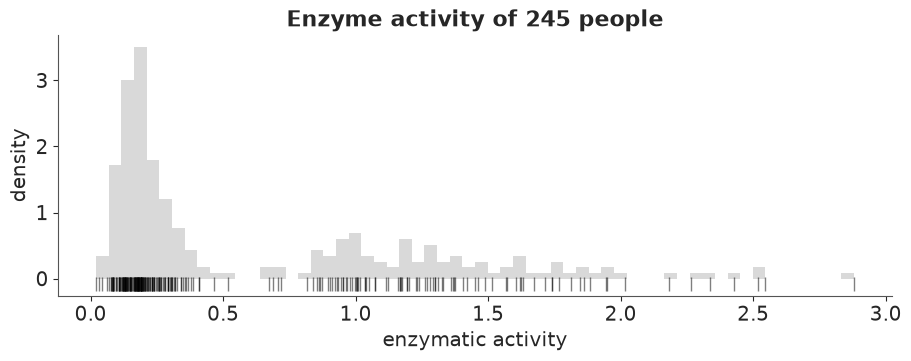

In [3]:
grid = np.linspace(-0.2, 3.2, 300)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(y, bins=60, density=True, color="0.85")
ax.plot(y, np.full(N, -0.08), "|", color="k", ms=10, alpha=0.5)
ax.set(xlabel="enzymatic activity", ylabel="density", title="Enzyme activity of 245 people");

Two groups, but not two bell curves. About two thirds of the people sit in a tight, steep
pile around 0.2 (the slow metabolisers). The rest spread from about 0.6 to 2.9 in a wide,
right-skewed hump. Bechtel et al. fitted *two skewed* distributions. A mixture of *normals*
will need more than two components to draw the same picture, and that is the first thing to
keep in mind: **a mixture component is a kernel, not a population**.

## 2 · The Dirichlet process in three pictures

A DP mixture says: there are infinitely many components, with weights
$w_1, w_2, \dots$ that sum to one, drawn by **stick-breaking**. Take a stick of length 1,
break off a fraction $v_1 \sim \text{Beta}(1, \alpha)$, that is $w_1$; break the fraction $v_2$
off what is left, that is $w_2 = v_2(1 - v_1)$; and so on:

$$w_k = v_k \prod_{\ell<k} (1 - v_\ell), \qquad v_k \sim \text{Beta}(1, \alpha).$$

Each component gets its own parameters $\theta_k$ drawn from a base distribution $G_0$. The
single **concentration** $\alpha$ sets how fast the stick is used up: small $\alpha$ gives a
few big weights, large $\alpha$ many small ones.

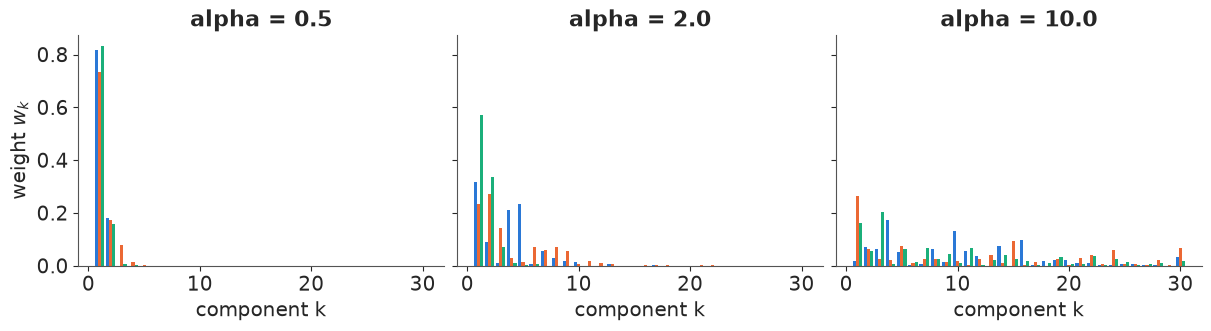

In [4]:
def stick_breaking(alpha, T, size, rng):
    v = rng.beta(1, alpha, size=(size, T))
    v[:, -1] = 1.0  # the last piece takes whatever is left
    return v * np.concatenate([np.ones((size, 1)), np.cumprod(1 - v[:, :-1], axis=1)], axis=1)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, a in zip(axes, [0.5, 2.0, 10.0]):
    for j, w in enumerate(stick_breaking(a, 30, 3, rng)):
        ax.bar(np.arange(1, 31) + (j - 1) * 0.28, w, width=0.28, color=[BLUE, ORANGE, AQUA][j])
    ax.set(title=f"alpha = {a}", xlabel="component k")
axes[0].set_ylabel("weight $w_k$");

### What $\alpha$ says about the number of clusters, before any data

With $n$ observations, each assigned to a component with probability $w_k$, the number of
**occupied** components $K_n$ is random, and its prior distribution depends on $\alpha$ and $n$
only: $E[K_n] = \sum_{i=1}^{n} \alpha / (\alpha + i - 1) \approx \alpha \log(1 + n/\alpha)$. So
the DP does **not** leave the number of clusters open - $\alpha$ sets it, and it grows with $n$.
The simplest way to see the prior is to simulate it. The Chinese-restaurant representation
needs no weights at all: observation $i$ opens a new cluster with probability
$\alpha / (\alpha + i - 1)$.

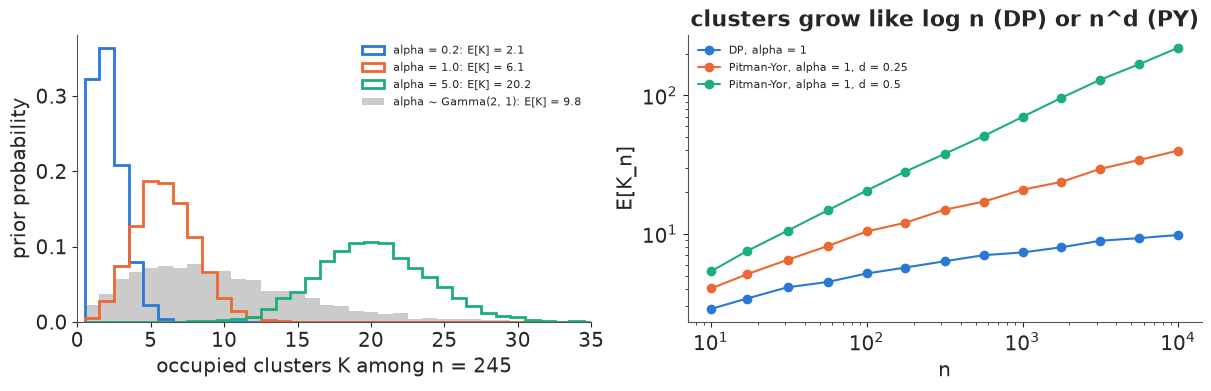

In [5]:
def prior_K(alpha, n, rng, discount=0.0):
    """Number of occupied clusters for n draws from a DP (or Pitman-Yor, discount > 0), vectorised over alpha."""
    alpha = np.atleast_1d(alpha).astype(float)
    K = np.zeros_like(alpha)
    for i in range(n):  # i = number already seated
        p_new = np.where(i == 0, 1.0, (alpha + discount * K) / (alpha + i))
        K += rng.random(alpha.shape) < p_new
    return K


fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for a, c in zip([0.2, 1.0, 5.0], [BLUE, ORANGE, AQUA]):
    K = prior_K(np.full(4000, a), N, rng)
    axes[0].hist(K, bins=np.arange(0.5, 40.5), density=True, histtype="step", lw=2, color=c,
                 label=f"alpha = {a}: E[K] = {K.mean():.1f}")
alpha_prior = rng.gamma(2.0, 1.0, size=4000)  # Gamma(shape 2, rate 1), used below
K_prior = prior_K(alpha_prior, N, rng)
axes[0].hist(K_prior, bins=np.arange(0.5, 40.5), density=True, color="0.6", alpha=0.5,
             label=f"alpha ~ Gamma(2, 1): E[K] = {K_prior.mean():.1f}")
axes[0].set(xlabel="occupied clusters K among n = 245", ylabel="prior probability", xlim=(0, 35))
axes[0].legend(fontsize=8)

ns = np.unique(np.logspace(1, 4, 13).astype(int))
for d, c, lab in [(0.0, BLUE, "DP, alpha = 1"), (0.25, ORANGE, "Pitman-Yor, alpha = 1, d = 0.25"),
                  (0.5, AQUA, "Pitman-Yor, alpha = 1, d = 0.5")]:
    EK = [prior_K(np.full(400, 1.0), n, rng, discount=d).mean() for n in ns]
    axes[1].plot(ns, EK, "o-", color=c, label=lab)
axes[1].set(xscale="log", yscale="log", xlabel="n", ylabel="E[K_n]", title="clusters grow like log n (DP) or n^d (PY)")
axes[1].legend(fontsize=8);

In [6]:
q = np.quantile(K_prior, [0.05, 0.5, 0.95])
print(f"alpha ~ Gamma(2, 1): prior K for n = {N}: median {q[1]:.0f}, 90% interval {q[0]:.0f}-{q[2]:.0f}")

alpha ~ Gamma(2, 1): prior K for n = 245: median 9, 90% interval 2-21


Three facts to take into the model. With $\alpha = 0.2$ the prior expects about two
clusters, with $\alpha = 5$ about twenty - for the same 245 people. The popular
$\alpha \sim \text{Gamma}(2, 1)$ is not "uninformative" about $K$: it spreads the prior over
2 to 21 occupied clusters with a median of 9. And the right panel shows the growth with $n$:
a DP expects more clusters in a bigger sample, forever, which is a modelling assumption
(new data keep revealing new kinds) and not an obvious one for a genetic polymorphism.

**Pitman-Yor aside.** The two-parameter Pitman-Yor process breaks the stick with
$v_k \sim \text{Beta}(1 - d, \alpha + k d)$, $0 \le d < 1$. The discount $d$ makes later
sticks longer than under the DP, so new clusters keep appearing at rate $n^d$ instead of
$\log n$, and cluster sizes follow a power law - the right prior for words in a corpus or
species in a sample, where there is no finite number of "types". For a handful of clusters
in 245 measurements it only makes the problem below (too many small clusters) worse, so we
stay with the DP.

## 3 · A truncated DP mixture of normals

NUTS cannot sample infinitely many sticks, so we **truncate** at $T$ components (the last
weight takes the remainder of the stick) and check afterwards that the truncation did not
bite. The prior mass beyond $T$ is on average $(\alpha / (1+\alpha))^{T-1}$: with
$\alpha \approx 2$ and $T = 20$ that is $4 \times 10^{-4}$.

`pm.StickBreakingWeights(alpha=..., K=T-1)` is the truncated stick-breaking distribution
(note: `K` counts the *breaks*, the output has $K+1$ weights). `pm.NormalMixture`
marginalises the discrete assignments, so the model is continuous and NUTS can sample it.

$$y_i \sim \sum_{k=1}^{T} w_k\, \text{Normal}(\mu_k, \sigma_k), \quad
w \sim \text{SB}_T(\alpha),\quad \alpha \sim \text{Gamma}(2, 1),\quad
\mu_k \sim \text{Normal}(\bar y, 2 s_y),\quad \sigma_k \sim \text{InvGamma}(2, 0.1).$$

The base distribution matters. $\sigma_k$ gets an inverse-gamma prior because it puts no
mass near zero: a normal mixture's likelihood is unbounded when one component shrinks onto a
single point, and a prior that allows $\sigma_k \to 0$ lets the sampler find those spikes.
The prior median of $\sigma_k$ is about 0.06 and its upper 5% point 0.3: small enough to
resolve the slow group, and several components can team up for the wide fast group.

In [7]:
T = 20


def dp_mixture(y, T, alpha=None):
    with pm.Model() as m:
        a = pm.Gamma("alpha", 2.0, 1.0) if alpha is None else alpha
        w = pm.StickBreakingWeights("w", alpha=a, K=T - 1)
        mu = pm.Normal("mu", y.mean(), 2 * y.std(), shape=T)
        sigma = pm.InverseGamma("sigma", 2.0, 0.1, shape=T)
        pm.NormalMixture("y", w=w, mu=mu, sigma=sigma, observed=y)
    return m


print(stats.invgamma(2.0, scale=0.1).ppf([0.05, 0.5, 0.95]).round(3))
dp = dp_mixture(y, T)
idata_dp = fit(dp)

[0.021 0.06  0.281]


     17 s, divergences per chain = [0 0 0 0]


### Diagnostics: the usual table is useless here

In [8]:
az.summary(idata_dp, var_names=["alpha", "mu"], round_to=2).iloc[:8]

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,1.44,0.72,0.54,2.72,105.31,156.10,1.03,0.06,0.03
mu[0],0.19,0.05,0.15,0.29,32.38,51.67,1.09,0.01,0.01
mu[1],1.30,0.27,0.95,1.75,29.54,77.99,1.10,0.04,0.02
mu[2],0.60,0.45,0.15,1.36,9.29,27.04,1.36,0.17,0.04
mu[3],0.80,0.70,0.13,2.14,17.07,53.92,1.20,0.18,0.05
mu[4],1.11,0.83,0.01,2.48,117.23,187.35,1.03,0.08,0.04
mu[5],1.02,0.98,-0.61,2.53,347.08,418.00,1.02,0.05,0.03
mu[6],0.91,1.07,-0.90,2.55,509.17,561.28,1.01,0.05,0.03


NUTS reports no divergences, $\alpha$ is fine, and the component means are a mess: $\hat R$
up to 1.36 and bulk ESS below 10 for some of them. This is not a sampling failure. The
component *labels* are not identified - the same density can be written with the
components in a different order - so "$\mu_3$" has no meaning of its own across chains.
Stick-breaking tempers the problem (component 1 tends to be the biggest), it does not remove
it. In C06 you fixed this with an ordering constraint; with 20 components, most of them
empty, an ordering on the means helps little, and it is simpler to stop asking about labels.

We need diagnostics of quantities that do not care what the components are called:
$\alpha$, the log density, and the **fitted density** $f(x) = \sum_k w_k
\text{Normal}(x \mid \mu_k, \sigma_k)$ at a grid of points.

In [9]:
def post_arrays(idata, names=("w", "mu", "sigma"), num_samples=None):
    """Posterior weights, means and sds as (chain, draw, T) arrays - or a stacked (sample, T) subsample."""
    if num_samples is None:
        return [idata.posterior[v].to_numpy() for v in names]
    ex = az.extract(idata, var_names=list(names), num_samples=num_samples, random_seed=RANDOM_SEED)
    return [ex[v].transpose("sample", ...).to_numpy() for v in names]


def mixture_density(w, mu, sigma, x):
    return (w[..., None, :] * stats.norm.pdf(x[:, None], mu[..., None, :], sigma[..., None, :])).sum(-1)


def label_free_diagnostics(idata, x_check=(0.15, 0.3, 0.8, 1.3, 2.0)):
    w, mu, sigma = post_arrays(idata)
    x_check = np.array(x_check)
    dens = xr.DataArray(mixture_density(w, mu, sigma, x_check), dims=("chain", "draw", "x"),
                        coords={"x": x_check})
    ds = xr.Dataset({"density": dens, "logp": idata.sample_stats["logp"]})
    return pd.DataFrame({"r_hat": az.rhat(ds)["density"].to_numpy(),
                         "ess_bulk": az.ess(ds)["density"].to_numpy()},
                        index=[f"f({x})" for x in x_check]).round(2), \
        float(az.rhat(ds)["logp"]), float(az.ess(ds)["logp"])


tab, rh, es = label_free_diagnostics(idata_dp)
print(f"log density: r_hat {rh:.2f}, ess {es:.0f}")
tab.T

log density: r_hat 1.02, ess 181


,f(0.15),f(0.3),f(0.8),f(1.3),f(2.0)
r_hat,1.00,1.00,1.00,1.00,1.02
ess_bulk,1132.64,1864.22,1358.96,1245.22,504.99


Every label-free quantity mixes: the density at five points has $\hat R \le 1.02$ and
bulk ESS in the hundreds to thousands. The log density ($\hat R$ 1.02, ESS 181) and $\alpha$
(ESS 105) are the slowest, which is typical: $\alpha$ is informed only through the *number*
of occupied components, and that number changes only when a component empties or fills.

### Is the truncation big enough?

If $T$ were too small, the last weight - which collects the whole rest of the stick - would
be visibly positive. Here it is the posterior of $w_T$ and of the total weight in the last
five components:

In [10]:
w_dp = idata_dp.posterior["w"]
print(f"w_T: mean {float(w_dp[..., -1].mean()):.1e}, 99th percentile {float(w_dp[..., -1].quantile(0.99)):.1e}")
print(f"weight in the last 5 components: 99th percentile {float(w_dp[..., -5:].sum('w_dim_0').quantile(0.99)):.1e}")
print("posterior mean of the sorted weights, per chain:")
print(np.sort(w_dp.to_numpy(), axis=-1)[..., ::-1].mean(1)[:, :7].round(3))

w_T: mean 2.6e-04, 99th percentile 5.0e-03
weight in the last 5 components: 99th percentile 1.5e-02
posterior mean of the sorted weights, per chain:
[[0.468 0.255 0.144 0.082 0.029 0.011 0.005]
 [0.445 0.265 0.144 0.075 0.035 0.016 0.008]
 [0.429 0.262 0.153 0.078 0.036 0.018 0.01 ]
 [0.451 0.253 0.152 0.081 0.032 0.014 0.007]]


The last component carries on average $3 \times 10^{-4}$ of the mass, and even the 99th
percentile of the last five together is 1.5%: 20 components are enough. The four chains agree on
the *sizes* of the components (the sorted weights), although, as we will see, not
necessarily on which component is which.

## 4 · Label-invariant summaries

### The density, with bands

The quantity a DP mixture estimates best is the density itself.

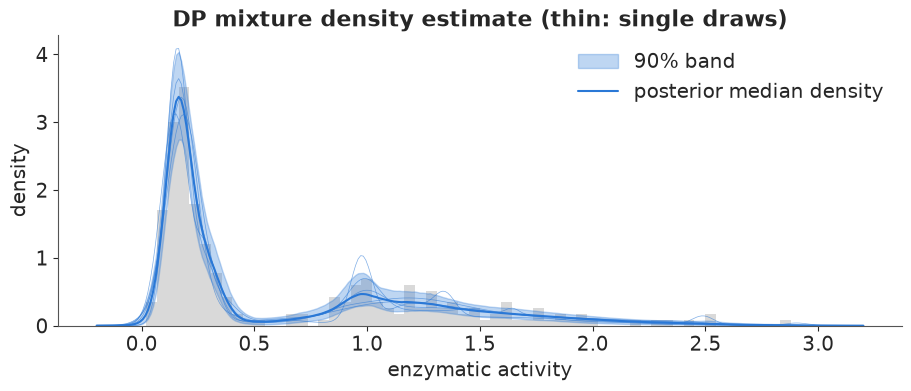

In [11]:
w_s, mu_s, sig_s = post_arrays(idata_dp, num_samples=1000)
dens_dp = mixture_density(w_s, mu_s, sig_s, grid)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(y, bins=60, density=True, color="0.85")
ax.fill_between(grid, *np.quantile(dens_dp, [0.05, 0.95], axis=0), color=BLUE, alpha=0.3, label="90% band")
ax.plot(grid, np.median(dens_dp, axis=0), color=BLUE, label="posterior median density")
for j in range(5):
    ax.plot(grid, dens_dp[j], color=BLUE, lw=0.5, alpha=0.6)
ax.set(xlabel="enzymatic activity", ylabel="density", title="DP mixture density estimate (thin: single draws)")
ax.legend();

### "How many clusters?" - three different answers

There are three quantities that could be called the number of clusters:

1. the number of **components**: $T = 20$ by construction (infinity for the untruncated DP);
2. the number of **occupied** clusters $K_{\text{occ}}$: the number of distinct labels when
   each person is allocated to a component. The assignments were marginalised out, so we
   draw them back: for posterior draw $s$, person $i$ goes to component $k$ with probability
   $\propto w_k^{(s)} \text{Normal}(y_i \mid \mu_k^{(s)}, \sigma_k^{(s)})$;
3. the number of components with a **non-negligible weight**, say $w_k > 0.02$.

,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
K_occ,0.0,0.01,0.10,0.16,0.20,0.16,0.10,0.11,0.07,0.03,0.03,0.02,0.01,0.01,0.0
w > 0.02,0.0,0.06,0.36,0.33,0.15,0.07,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
>= 5 people,0.0,0.05,0.35,0.31,0.19,0.07,0.03,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.0


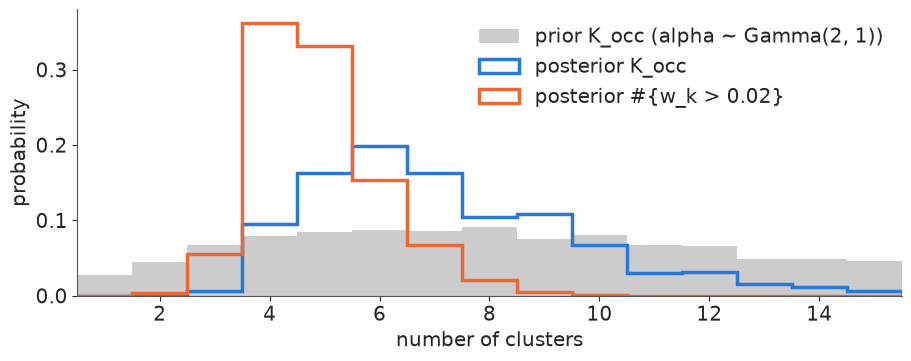

In [12]:
def allocations(w, mu, sigma, y, rng):
    """Draw one allocation vector per posterior draw (S x N) from the marginalised model."""
    logp = np.log(np.maximum(w, 1e-300))[:, None, :] + stats.norm.logpdf(y[None, :, None], mu[:, None, :], sigma[:, None, :])
    p = np.exp(logp - logp.max(-1, keepdims=True))
    p /= p.sum(-1, keepdims=True)
    return (p.cumsum(-1) < rng.random(p.shape[:2])[..., None]).sum(-1)


def n_occupied(z):
    return np.array([len(np.unique(row)) for row in z])


z_dp = allocations(w_s, mu_s, sig_s, y, rng)
K_occ = n_occupied(z_dp)
K_big = (w_s > 0.02).sum(1)
K_big_occ = np.array([(np.bincount(row, minlength=T) >= 0.02 * N).sum() for row in z_dp])

fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.arange(0.5, 16.5)
ax.hist(K_prior, bins=bins, density=True, color="0.8", label="prior K_occ (alpha ~ Gamma(2, 1))")
ax.hist(K_occ, bins=bins, density=True, histtype="step", lw=2.5, color=BLUE, label="posterior K_occ")
ax.hist(K_big, bins=bins, density=True, histtype="step", lw=2.5, color=ORANGE, label="posterior #{w_k > 0.02}")
ax.set(xlabel="number of clusters", ylabel="probability", xlim=(0.5, 15.5))
ax.legend()
pd.DataFrame({"K_occ": pd.Series(K_occ).value_counts(normalize=True),
              "w > 0.02": pd.Series(K_big).value_counts(normalize=True),
              ">= 5 people": pd.Series(K_big_occ).value_counts(normalize=True)}).sort_index().fillna(0).round(2).T

The three counts disagree, and that is the point. $K_{\text{occ}}$ has a median of 7 and a
long right tail: a DP routinely opens small clusters with one or two people in them,
because under its prior a new cluster is always possible and a single outlying value
is cheaply explained by one. Counting only components with more than 2% of the weight - or,
nearly the same, with at least 5 people - gives 4 or 5. None of them is 2, the number of
biological groups: the fast group is skewed, and normal kernels need two or three to draw it.
Compared with the prior (grey), the data have ruled out 1-3 clusters and very many clusters,
but the posterior of $K_{\text{occ}}$ is still wide. Miller & Harrison (2014) showed this is
not a small-sample accident: the DP mixture posterior of the number of clusters is
*inconsistent* - even with infinitely many observations from a finite mixture it does not
concentrate on the true number. The DP is a tool for density estimation; counting its
clusters is a separate, prior-driven question.

### Who belongs with whom: the co-clustering matrix

Labels switch; *pairs* do not. The posterior **similarity matrix** $P_{ij}$ = probability that
persons $i$ and $j$ are in the same cluster is label-invariant, and the whole clustering
posterior can be read from it. Because the data are one-dimensional and sorted, clusters
show up as blocks on the diagonal.

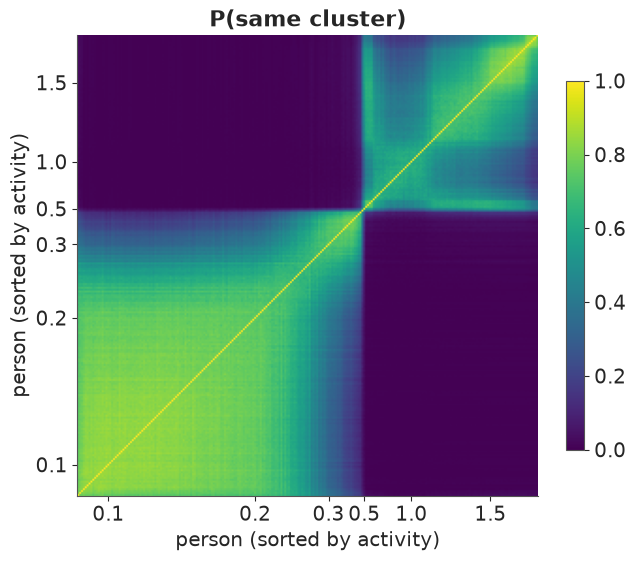

In [13]:
def similarity(z, T):
    onehot = np.eye(T, dtype=np.float32)[z]  # S x N x T
    return np.einsum("snk,smk->nm", onehot, onehot) / len(z)


psm_dp = similarity(z_dp, T)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(psm_dp, cmap="viridis", vmin=0, vmax=1, origin="lower")
tick_values = [0.1, 0.2, 0.3, 0.5, 1.0, 1.5]
ticks = np.searchsorted(y, tick_values)
ax.set(xticks=ticks, yticks=ticks, xticklabels=tick_values, yticklabels=tick_values,
       xlabel="person (sorted by activity)", ylabel="person (sorted by activity)", title="P(same cluster)")
fig.colorbar(im, ax=ax, shrink=0.8);

Two dark off-diagonal blocks say that nobody below about 0.45 is ever clustered with
anybody above 0.6: the slow/fast split is certain. Within the slow group the co-clustering
is high but fades towards its upper edge (about 0.25-0.45), where people are sometimes put in a
small extra component. The fast group is much less coherent: it is carved into two or three
kernels in varying ways, so its pairwise probabilities sit between 0.3 and 0.8.

### A single "best" clustering

A report usually wants *one* partition. The Bayesian answer is the partition that minimises
the posterior expected loss. Two losses are standard (Wade & Ghahramani 2018):

- **Binder's loss** counts the pairs on which two partitions disagree. Its expectation needs
  only the similarity matrix: $\sum_{i<j} |\mathbb{1}[c_i = c_j] - P_{ij}|$.
- The **variation of information** (VI) is an information-theoretic distance between
  partitions. Its expectation has a cheap lower bound that also uses only $P$:
  $\frac1N \sum_i \big[\log_2 \sum_j \mathbb{1}[c_j{=}c_i] + \log_2 \sum_j P_{ij}
  - 2 \log_2 \sum_j \mathbb{1}[c_j{=}c_i] P_{ij}\big]$.

Binder's loss is known to favour extra small clusters, VI to favour fewer, larger ones.
Searching all partitions is impossible; the usual shortcut is to score the sampled partitions
plus the cuts of a hierarchical clustering on $1 - P$, and keep the best.

In [14]:
def binder_loss(c, psm):
    same = c[:, None] == c[None, :]
    return np.abs(same - psm)[np.triu_indices(len(c), 1)].sum()


def vi_lower_bound(c, psm):
    same = (c[:, None] == c[None, :]).astype(float)
    return np.mean(np.log2(same.sum(1)) + np.log2(psm.sum(1)) - 2 * np.log2((same * psm).sum(1)))


def point_clustering(z, psm, loss):
    tree = linkage(squareform(1 - psm, checks=False), method="average")
    candidates = [fcluster(tree, k, criterion="maxclust") for k in range(1, 16)] + list(z[:200])
    scores = [loss(c, psm) for c in candidates]
    best = candidates[int(np.argmin(scores))]
    return pd.Index(pd.unique(best)).get_indexer(best)  # relabel 0, 1, ... in order of appearance


def describe_clusters(c):
    return pd.DataFrame({"y": y, "c": c}).groupby("c").y.agg(["size", "min", "max", "mean"]).round(2)


c_vi = point_clustering(z_dp, psm_dp, vi_lower_bound)
c_binder = point_clustering(z_dp, psm_dp, binder_loss)
print("VI-optimal clustering:")
print(describe_clusters(c_vi))
print("Binder-optimal clustering:")
print(describe_clusters(c_binder))

VI-optimal clustering:
   size   min   max  mean
c                        
0   151  0.02  0.41  0.19
1    94  0.47  2.88  1.31
Binder-optimal clustering:
   size   min   max  mean
c                        
0   116  0.02  0.25  0.16
1    35  0.25  0.41  0.31
2     2  0.47  0.52  0.49
3    60  0.67  2.88  1.53
4    32  0.82  1.11  0.96


Here the two losses tell different stories from the same posterior. The VI-optimal partition
is exactly the biological answer: 151 slow metabolisers (activity up to 0.41) and 94 fast
ones (from 0.47) - the split Bechtel et al. found with two skewed distributions. Binder's loss
keeps five clusters, splitting both groups and isolating two people around 0.5. Neither is
"the" answer; they are optimal for different questions (VI: a coarse, stable summary;
Binder: penalise every mis-paired couple equally). Whichever you report, report the
similarity matrix next to it.

## 5 · How much does $\alpha$ decide?

Refit with $\alpha$ fixed at three values instead of learning it, and with the truncation
cut to $T = 5$. Everything else is identical.

In [15]:
fits = {}
for label, model in [("alpha = 0.2", dp_mixture(y, T, alpha=0.2)),
                     ("alpha = 5", dp_mixture(y, T, alpha=5.0)),
                     ("T = 5", dp_mixture(y, 5))]:
    print(label)
    fits[label] = fit(model)

alpha = 0.2


     14 s, divergences per chain = [0 0 0 0]
alpha = 5


     31 s, divergences per chain = [0 0 0 0]
T = 5


      3 s, divergences per chain = [0 0 0 0]


In [16]:
rows, dens_by = [], {"alpha ~ Gamma(2, 1), T = 20": dens_dp}
Ks = {"alpha ~ Gamma(2, 1), T = 20": K_occ}
for label, idata in fits.items():
    ws, ms, ss = post_arrays(idata, num_samples=1000)
    Ks[label] = n_occupied(allocations(ws, ms, ss, y, rng))
    dens_by[label] = mixture_density(ws, ms, ss, grid)
    rows.append((label, ws[:, -1].mean(), np.quantile(ws[:, -1], 0.99)))
for label, K in Ks.items():
    print(f"{label:30s} K_occ median {np.median(K):4.0f}, 90% interval {np.quantile(K, 0.05):.0f}-{np.quantile(K, 0.95):.0f}")
pd.DataFrame(rows, columns=["fit", "mean w_T", "99% w_T"]).set_index("fit").map(lambda v: f"{v:.1e}")

alpha ~ Gamma(2, 1), T = 20    K_occ median    7, 90% interval 4-12
alpha = 0.2                    K_occ median    4, 90% interval 2-6
alpha = 5                      K_occ median   14, 90% interval 10-18
T = 5                          K_occ median    5, 90% interval 4-5


,mean w_T,99% w_T
fit,,
alpha = 0.2,4.8e-18,9.6e-20
alpha = 5,1.7e-02,9.0e-02
T = 5,2.3e-01,5.8e-01


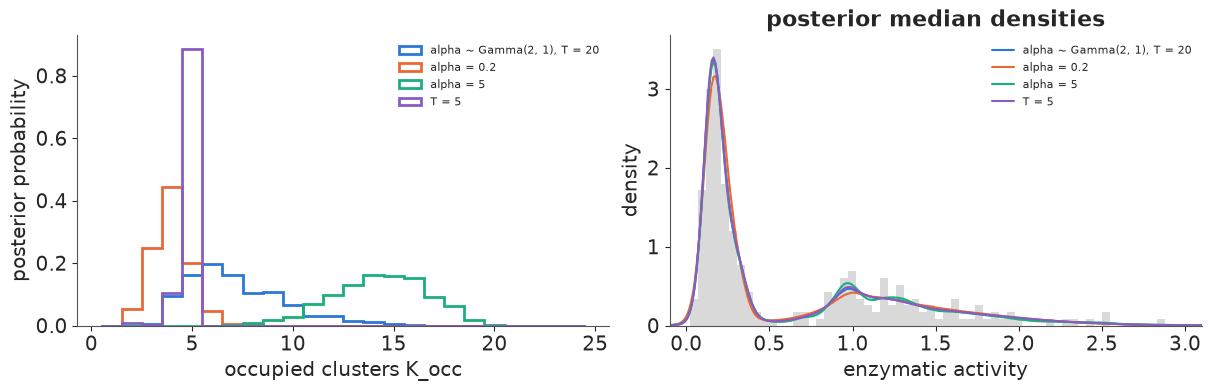

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (label, K), c in zip(Ks.items(), [BLUE, ORANGE, AQUA, PURPLE]):
    axes[0].hist(K, bins=np.arange(0.5, 25.5), density=True, histtype="step", lw=2, color=c, label=label)
    axes[1].plot(grid, np.median(dens_by[label], axis=0), color=c, label=label)
axes[0].set(xlabel="occupied clusters K_occ", ylabel="posterior probability")
axes[0].legend(fontsize=8)
axes[1].hist(y, bins=60, density=True, color="0.85")
axes[1].set(xlabel="enzymatic activity", ylabel="density", xlim=(-0.1, 3.1), title="posterior median densities")
axes[1].legend(fontsize=8);

**The density is robust, the cluster count is not.** The four posterior median densities are
nearly indistinguishable, but $K_{\text{occ}}$ runs from a median of 4 ($\alpha = 0.2$) to 14
($\alpha = 5$): with 245 observations the prior on $\alpha$ still decides the count. Learning
$\alpha$ does not escape this - it simply moves the choice to the hyperprior (Gamma(2, 1)
gave 7).

**Two truncation failures.** With $\alpha = 5$ the stick is used up slowly: the last of 20
components carries 1.7% of the mass on average (up to 9%), so the truncation is biting and
$T$ would have to go up (to about 50 for a tail below $10^{-4}$). With $T = 5$ it bites hard:
$w_T$ averages 0.23, and the posterior of $K_{\text{occ}}$ is piled against the ceiling of 5.
A $K_{\text{occ}}$ posterior that touches $T$ is the same alarm in another form. Notice that
neither failure shows in the density, or in the sampler diagnostics: only the last-stick
check catches it.

### Mixing across chains

The stick-breaking weights are **not exchangeable**: component 1 is a priori the biggest,
component 2 the next, and so on. So relabelling two components changes the prior density,
and the posterior has many *unequal* modes, one per plausible ordering. NUTS moves between
them only rarely, so different chains can settle on different orderings - harmless for
label-invariant summaries **if** each chain explores the same clustering distribution.
Compare the chains on $K_{\text{occ}}$:

In [18]:
w_c, mu_c, sig_c = post_arrays(fits["alpha = 0.2"])
per_chain = {f"chain {ch}": pd.Series(n_occupied(allocations(w_c[ch, ::2], mu_c[ch, ::2], sig_c[ch, ::2], y, rng))).value_counts(normalize=True)
             for ch in range(w_c.shape[0])}
print("alpha = 0.2: posterior of K_occ in each chain")
print(pd.DataFrame(per_chain).sort_index().fillna(0).round(2).T)
tab, rh, es = label_free_diagnostics(fits["alpha = 0.2"])
print(f"log density: r_hat {rh:.2f}, ess {es:.0f}")
tab.T

alpha = 0.2: posterior of K_occ in each chain
            2     3     4     5     6     7    8    9
chain 0  0.16  0.34  0.34  0.13  0.02  0.01  0.0  0.0
chain 1  0.00  0.03  0.57  0.29  0.08  0.03  0.0  0.0
chain 2  0.02  0.32  0.36  0.23  0.06  0.00  0.0  0.0
chain 3  0.05  0.40  0.42  0.11  0.02  0.00  0.0  0.0
log density: r_hat 1.07, ess 49


,f(0.15),f(0.3),f(0.8),f(1.3),f(2.0)
r_hat,1.15,1.00,1.01,1.02,1.03
ess_bulk,18.71,876.24,789.10,225.86,169.52


Chain 1 almost never visits $K_{\text{occ}} \le 3$, the others do in 35-50% of their draws,
and the density at 0.15 has $\hat R = 1.15$ with a bulk ESS of 19. The chains are stuck in
different orderings with different cluster structures, and with $\alpha = 0.2$ it is costly
to open or close a component, so they do not trade. (In the fit with $\alpha$ learned, the
same checks gave $\hat R \le 1.02$.) Remedies, from cheap to expensive: more
chains and longer runs, judged by label-free $\hat R$; starting chains from different
clusterings; or a sampler that updates assignments directly (Gibbs / split-merge moves for
the conditional or marginal DP representation), which is what the specialised DP software
does and what NUTS on the marginalised model cannot.

## 6 · A sparse finite mixture

Malsiner-Walli, Frühwirth-Schnatter & Grün (2016) turn the question around: fit a *finite*
mixture with deliberately too many components, $K = 10$, and a symmetric
$\text{Dirichlet}(e_0, \dots, e_0)$ prior on the weights with a tiny $e_0$ (they recommend
0.01 or smaller). The prior
then wants most components **empty**, and superfluous components are emptied rather than
split off. Unlike the DP, the weights are exchangeable, and the prior number of clusters does
not grow with $n$.

### The textbook setting, $e_0 = 0.01$, under NUTS

We try it twice: with PyMC's `pm.Dirichlet`, and with a reparameterisation that often helps
with small Dirichlet parameters. A Dirichlet vector is a set of independent Gamma variables
divided by their sum, $g_k \sim \text{Gamma}(e_0, 1)$, $w_k = g_k / \sum_j g_j$, so we can
sample $\log g_k$ instead of the simplex: $K$ coordinates that are independent a priori,
each with the smooth density $\propto \exp(e_0 x - e^x)$. PyMC derives the density of
`pt.log(Gamma)` automatically. Everything then stays on the log scale
($\log w = \log g - \text{logsumexp}(\log g)$) and the mixture likelihood is written with
`logsumexp`, because an empty component's weight can underflow to exactly zero.

In [19]:
K_sfm = 10


def mixture_logp(value, logw, mu, sigma):
    return pt.logsumexp(logw + pm.logp(pm.Normal.dist(mu, sigma), value[..., None]), axis=-1)


def sparse_mixture(y, e0, log_gamma=False):
    with pm.Model() as m:
        if log_gamma:
            log_g = pm.CustomDist("log_g", e0, dist=lambda a, size: pt.log(pm.Gamma.dist(a, 1.0, size=size)), shape=K_sfm)
            logw = log_g - pt.logsumexp(log_g)
        else:
            logw = pt.log(pm.Dirichlet("w_raw", np.full(K_sfm, e0)))
        pm.Deterministic("w", pt.exp(logw))
        mu = pm.Normal("mu", y.mean(), 2 * y.std(), shape=K_sfm)
        sigma = pm.InverseGamma("sigma", 2.0, 0.1, shape=K_sfm)
        pm.CustomDist("y", logw, mu, sigma, logp=mixture_logp, observed=y)
    return m


def sampler_health(idata):
    ss = idata.sample_stats
    tab, _, _ = label_free_diagnostics(idata)
    return {"divergences": int(ss["diverging"].sum()),
            "step size (per chain)": " ".join(f"{v:.0e}" for v in ss["step_size"].mean("draw").to_numpy()),
            "tree depth (per chain)": " ".join(f"{v:.1f}" for v in ss["depth"].mean("draw").to_numpy()),
            "max r_hat of f(x)": round(float(tab["r_hat"].max()), 2),
            "min ess of f(x)": round(float(tab["ess_bulk"].min()))}


health = {}
for label, model in [("Dirichlet, e0 = 0.01", sparse_mixture(y, 0.01)),
                     ("log-gamma, e0 = 0.01", sparse_mixture(y, 0.01, log_gamma=True))]:
    print(label)
    idata_tmp = fit(model)
    health[label] = sampler_health(idata_tmp)
    del idata_tmp
pd.DataFrame(health).T

Dirichlet, e0 = 0.01


     43 s, divergences per chain = [ 0  1  9 60]
log-gamma, e0 = 0.01


     38 s, divergences per chain = [  0   0   0 993]


,divergences,step size (per chain),tree depth (per chain),max r_hat of f(x),min ess of f(x)
"Dirichlet, e0 = 0.01",70,1e-02 2e-02 1e-02 6e-03,10.0 9.6 9.5 9.1,1.01,408
"log-gamma, e0 = 0.01",993,2e-05 9e-06 6e-05 1e-05,10.0 10.0 10.0 1.5,2.83,5


Two different failures. With `pm.Dirichlet`, 70 divergences in three of four chains, step
sizes around 0.01 and trees at or near the maximum depth of 10: the fitted
density still agrees across chains ($\hat R$ 1.01), but the sampler is not exploring the
prior region where most components are empty and it says so. The log-gamma version is
*worse*: three chains without a single divergence ran with step sizes of $10^{-5}$ and
saturated trees - frozen in place, $\hat R$ of the density 2.83, ESS 5 - and the fourth
diverged on almost every draw. **Zero divergences is not a clean bill of health**; the step
size and the label-free $\hat R$ gave it away.

The cause is the prior itself. $\text{Gamma}(0.01, 1)$ puts $\log g_k$ of an empty component
on an exponential tail with scale $1/e_0 = 100$, while occupied components have $\log w_k$
determined to $\pm 0.1$: a thousandfold difference in scale that swaps between coordinates
whenever a component empties or fills. No mass matrix fits both. A Gibbs sampler (what
Malsiner-Walli et al. use) updates the allocations and never sees this geometry. For NUTS
the practical fix is a less extreme $e_0$. What does that cost? The implied prior on
$K_{\text{occ}}$, simulated the same way as for the DP:

In [20]:
def prior_K_sparse(e0, K, n, size, rng):
    """Prior of the number of occupied components of a Dirichlet(e0) mixture, on the log scale."""
    log_g = np.log(rng.random((size, K))) / e0 + np.log(rng.gamma(e0 + 1.0, size=(size, K)))
    w = np.exp(log_g - log_g.max(1, keepdims=True))
    counts = rng.multinomial(n, w / w.sum(1, keepdims=True))
    return (counts > 0).sum(1)


for e0 in [0.01, 0.05, 0.1]:
    Kp = prior_K_sparse(e0, K_sfm, N, 20000, rng)
    print(f"e0 = {e0}: prior K_occ", pd.Series(Kp).value_counts(normalize=True).sort_index().round(2).to_dict())

e0 = 0.01: prior K_occ {1: 0.59, 2: 0.32, 3: 0.08, 4: 0.01, 5: 0.0, 6: 0.0}
e0 = 0.05: prior K_occ {1: 0.08, 2: 0.24, 3: 0.31, 4: 0.23, 5: 0.1, 6: 0.03, 7: 0.01, 8: 0.0, 9: 0.0}
e0 = 0.1: prior K_occ {1: 0.01, 2: 0.05, 3: 0.16, 4: 0.26, 5: 0.26, 6: 0.16, 7: 0.07, 8: 0.02, 9: 0.0, 10: 0.0}


In [21]:
print("Dirichlet, e0 = 0.05")
sfm = sparse_mixture(y, 0.05)
idata_sfm = fit(sfm)
health["Dirichlet, e0 = 0.05"] = sampler_health(idata_sfm)
display(pd.DataFrame(health).T)

w_f, mu_f, sig_f = post_arrays(idata_sfm, num_samples=1000)
z_sfm = allocations(w_f, mu_f, sig_f, y, rng)
K_occ_sfm = n_occupied(z_sfm)
print("sparse finite mixture (e0 = 0.05), posterior of K_occ:")
print(pd.Series(K_occ_sfm).value_counts(normalize=True).sort_index().round(2).to_dict())
psm_sfm = similarity(z_sfm, K_sfm)
c_sfm = point_clustering(z_sfm, psm_sfm, vi_lower_bound)
print("VI-optimal clustering:")
print(describe_clusters(c_sfm))
print("Binder-optimal clustering:")
print(describe_clusters(point_clustering(z_sfm, psm_sfm, binder_loss)))

Dirichlet, e0 = 0.05


     41 s, divergences per chain = [0 0 0 0]


,divergences,step size (per chain),tree depth (per chain),max r_hat of f(x),min ess of f(x)
"Dirichlet, e0 = 0.01",70,1e-02 2e-02 1e-02 6e-03,10.0 9.6 9.5 9.1,1.01,408
"log-gamma, e0 = 0.01",993,2e-05 9e-06 6e-05 1e-05,10.0 10.0 10.0 1.5,2.83,5
"Dirichlet, e0 = 0.05",0,3e-02 2e-02 3e-02 2e-02,9.7 9.7 9.6 9.8,1.0,949


sparse finite mixture (e0 = 0.05), posterior of K_occ:
{2: 0.01, 3: 0.13, 4: 0.44, 5: 0.31, 6: 0.09, 7: 0.02, 8: 0.0}


VI-optimal clustering:
   size   min   max  mean
c                        
0   151  0.02  0.41  0.19
1    94  0.47  2.88  1.31
Binder-optimal clustering:
   size   min   max  mean
c                        
0   131  0.02  0.31  0.17
1    19  0.28  0.41  0.33
2    86  0.41  2.02  1.20
3     9  1.71  2.88  2.29


With $e_0 = 0.05$ the prior still favours few clusters (median 3, and it will not grow
with $n$), and NUTS is healthy: no divergences, step size 0.02-0.03, density $\hat R$ 1.00 and
ESS above 900 - at the price of deep trees (several hundred gradient evaluations per draw). The
posterior of $K_{\text{occ}}$ is tighter than the DP's, 4 or 5 with 75% probability and
almost never above 7: the sparse prior empties superfluous components instead of keeping
small ones alive, which is the sense in which it is better behaved for counting clusters.
The VI-optimal partition is again the 151/94 slow/fast split; Binder's keeps four clusters.

## 7 · Finite mixtures with $K$ chosen by LOO

The classical route: fit $K = 2, \dots, 5$ with ordered means (to kill label switching;
starting values via `pm.sample(initvals=...)` because `initval=` breaks
`pm.compute_log_likelihood`) and compare by PSIS-LOO. The DP and sparse mixtures go into the
same comparison.

In [22]:
def finite_mixture(y, K):
    with pm.Model() as m:
        w = pm.Dirichlet("w", np.ones(K))
        mu = pm.Normal("mu", y.mean(), 2 * y.std(), shape=K, transform=pm.distributions.transforms.ordered)
        sigma = pm.InverseGamma("sigma", 2.0, 0.1, shape=K)
        pm.NormalMixture("y", w=w, mu=mu, sigma=sigma, observed=y)
    return m


def loo_of(model, idata):
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)
    loo = az.loo(idata, pointwise=True)
    loo.log_weights = None
    return loo


loos, finite_rhat = {}, {}
for K in [2, 3, 4, 5]:
    print(f"K = {K}")
    m = finite_mixture(y, K)
    idata_K = fit(m, initvals={"mu": np.quantile(y, (np.arange(K) + 0.5) / K)})
    finite_rhat[K] = float(az.rhat(idata_K, var_names=["mu"])["mu"].max())
    loos[f"finite K={K}"] = loo_of(m, idata_K)
    del idata_K
print("max r_hat of the ordered means:", {k: round(v, 2) for k, v in finite_rhat.items()})
loos["DP, alpha ~ Gamma(2,1)"] = loo_of(dp, idata_dp)
loos["sparse finite, K=10"] = loo_of(sfm, idata_sfm)
cmp = az.compare(loos, round_to=1)
cmp

K = 2


      1 s, divergences per chain = [0 0 0 0]
K = 3


      2 s, divergences per chain = [0 0 0 0]


K = 4


      2 s, divergences per chain = [0 0 0 0]


K = 5


      3 s, divergences per chain = [0 0 0 0]


max r_hat of the ordered means: {2: 1.0, 3: 1.64, 4: 1.01, 5: 1.03}


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
finite K=5,0,0.0,0.0,NaN,,,12.4,-52.0,20.3,0.9
finite K=4,1,-0.5,0.7,0.8,|elpd_diff| < 4,,11.4,-52.5,20.3,0.0
"DP, alpha ~ Gamma(2,1)",2,-2.5,0.6,1.0,|elpd_diff| < 4,,14.6,-54.4,20.4,0.0
"sparse finite, K=10",3,-3.2,1.1,1.0,|elpd_diff| < 4,,13.6,-55.2,20.3,0.0
finite K=3,4,-6.7,2.7,1.0,,,12.4,-58.7,20.4,0.0
finite K=2,5,-7.8,4.4,1.0,,,5.3,-59.8,20.5,0.1


Two normals are clearly not enough (K = 2 is 8 elpd behind), three nearly so, and from four
components on every model predicts about equally well: finite $K = 4$ and $K = 5$, the DP and
the sparse mixture are within 3.2 elpd of each other, and ArviZ flags all these differences
as below 4, too small to trust. So LOO says "at least four normal kernels" - a statement
about how many *normals* it takes to draw a skewed density, not about how many kinds of
people there are. (Note also $\hat R = 1.64$ for $K = 3$ even with ordered means: the chains
disagree about how to spend three kernels on two skewed groups.) The DP and the sparse
mixture reach the same predictive accuracy without choosing $K$ at all, and their
co-clustering tells the biological story that no single finite fit does.

## 8 · Where a DP mixture earns its keep: a flexible random-effects distribution

The most useful DP mixtures are not the ones whose clusters you interpret, but the ones that
replace a Normal assumption inside a bigger model. Take the Mayo Clinic trial in primary
biliary cholangitis: serum bilirubin measured repeatedly (1-16 visits) on 312 patients. On
the log scale, each patient's trajectory is roughly a line,

$$\log \text{bili}_{ij} = a_i + b_i t_{ij} + \varepsilon_{ij}, \qquad t \text{ in years}.$$

The standard model puts $b_i \sim \text{Normal}(\mu_b, \sigma_b)$. But a liver disease has
patients who are stable and patients who progress: the distribution of slopes may be skewed,
and a Normal would then misjudge exactly the quantity a clinician cares about - how many
patients progress fast. Replace the Normal by a DP mixture of normals, again with
`pm.NormalMixture`, now as a *prior* on the 312 latent slopes.

In [23]:
data.describe("pbcseq")
pbc = data.load("pbcseq")
pid, patients = pd.factorize(pbc["id"])
t_yr = (pbc["day"] / 365.25).to_numpy()
log_bili = np.log(pbc["bili"].to_numpy())
print(f"{len(pbc)} visits of {len(patients)} patients; follow-up up to {t_yr.max():.1f} years")


def slope_model(kind, T_re=10):
    with pm.Model(coords={"patient": patients}) as m:
        mu_a = pm.Normal("mu_a", 0.0, 2.0)
        s_a = pm.HalfNormal("s_a", 1.5)
        a = pm.Normal("a", mu_a, s_a, dims="patient")
        if kind == "normal":
            mu_b = pm.Normal("mu_b", 0.0, 0.5)
            s_b = pm.HalfNormal("s_b", 0.5)
            z = pm.Normal("z", 0.0, 1.0, dims="patient")
            b = pm.Deterministic("b", mu_b + s_b * z, dims="patient")
        else:
            alpha = pm.Gamma("alpha", 2.0, 1.0)
            w = pm.StickBreakingWeights("w", alpha=alpha, K=T_re - 1)
            m_b = pm.Normal("m_b", 0.0, 0.5, shape=T_re)
            s_b = pm.InverseGamma("s_b", 3.0, 0.2, shape=T_re)
            b = pm.NormalMixture("b", w=w, mu=m_b, sigma=s_b, dims="patient")
        sigma = pm.HalfNormal("sigma", 1.0)
        pm.Normal("y", a[pid] + b[pid] * t_yr, sigma, observed=log_bili)
    return m


slope_fits, slope_loos = {}, {}
for kind in ["normal", "dp"]:
    print(kind)
    m = slope_model(kind)
    slope_fits[kind] = fit(m, target_accept=0.9)
    slope_loos[kind] = loo_of(m, slope_fits[kind])
print(az.summary(slope_fits["normal"], var_names=["mu_b", "s_b", "sigma"], round_to=3))
print(az.summary(slope_fits["dp"], var_names=["alpha", "sigma"], round_to=3))
print("max r_hat of the 312 slopes:", {k: round(float(az.rhat(v, var_names=["b"])["b"].max()), 3) for k, v in slope_fits.items()})
az.compare(slope_loos, round_to=1)

pbcseq: 1945 visits of the 312 randomised patients: serum bilirubin (mg/dl) and other labs at each `day`, plus follow-up `futime` (days) and `status` (0 censored, 1 liver transplant, 2 death); `trt` 1 = D-penicillamine, 0 = placebo.
  source: Mayo Clinic trial in primary biliary cholangitis (cirrhosis), 1974-1984, D-penicillamine vs placebo; Murtaugh et al. (1994, Hepatology 20:126), Fleming & Harrington (1991), via R package `survival`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/survival/pbcseq.csv
1945 visits of 312 patients; follow-up up to 14.1 years
normal


      1 s, divergences per chain = [0 0 0 0]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


dp


     10 s, divergences per chain = [0 0 0 0]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
mu_b   0.162  0.013     0.141     0.183   297.821   439.512  1.005      0.001   
s_b    0.174  0.012     0.155     0.192   543.634   871.841  1.003      0.001   
sigma  0.348  0.007     0.338     0.359  2478.542  2674.381  1.001      0.000   

       mcse_sd  
mu_b       0.0  
s_b        0.0  
sigma      0.0  
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
alpha  1.628  1.052     0.481     3.560   125.170   125.424  1.031      0.069   
sigma  0.344  0.007     0.334     0.355   576.362   696.508  1.010      0.000   

       mcse_sd  
alpha    0.049  
sigma    0.000  


max r_hat of the 312 slopes: {'normal': 1.004, 'dp': 1.022}


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
dp,0,0.0,0.0,NaN,,113 k̂ > 0.70,502.7,-1015.6,51.6,0.6
normal,1,-6.7,7.4,0.8,,89 k̂ > 0.70,487.0,-1022.3,50.0,0.4


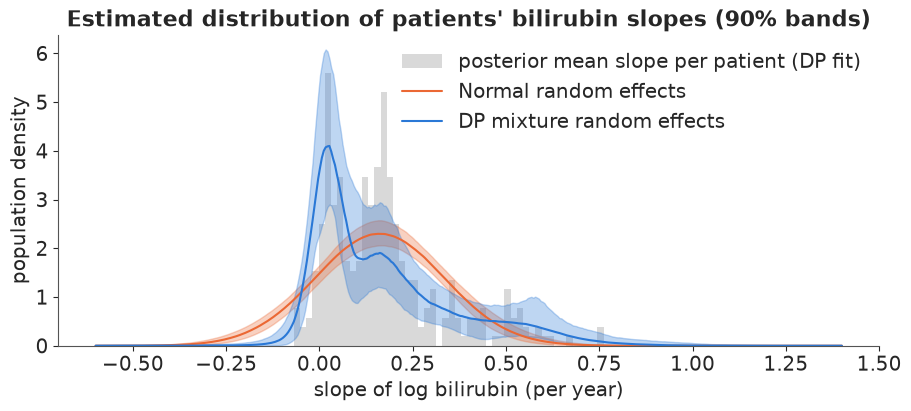

In [24]:
b_grid = np.linspace(-0.6, 1.4, 400)
post_n = az.extract(slope_fits["normal"], var_names=["mu_b", "s_b"], num_samples=1000, random_seed=RANDOM_SEED)
dens_n = stats.norm.pdf(b_grid[None, :], post_n["mu_b"].to_numpy()[:, None], post_n["s_b"].to_numpy()[:, None])
wd, md, sd = post_arrays(slope_fits["dp"], names=("w", "m_b", "s_b"), num_samples=1000)
dens_d = mixture_density(wd, md, sd, b_grid)
b_mean = {k: v.posterior["b"].mean(("chain", "draw")).to_numpy() for k, v in slope_fits.items()}

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(b_mean["dp"], bins=50, density=True, color="0.85", label="posterior mean slope per patient (DP fit)")
for dens, c, lab in [(dens_n, ORANGE, "Normal random effects"), (dens_d, BLUE, "DP mixture random effects")]:
    ax.fill_between(b_grid, *np.quantile(dens, [0.05, 0.95], axis=0), color=c, alpha=0.3)
    ax.plot(b_grid, np.median(dens, axis=0), color=c, label=lab)
ax.set(xlabel="slope of log bilirubin (per year)", ylabel="population density",
       title="Estimated distribution of patients' bilirubin slopes (90% bands)")
ax.legend();

In [25]:
def tail_probs(dens):
    step = b_grid[1] - b_grid[0]
    fast = dens[:, b_grid > np.log(2) / 2].sum(1) * step  # doubling within 2 years
    falling = dens[:, b_grid < 0].sum(1) * step
    return fast, falling


for lab, dens in [("Normal", dens_n), ("DP mixture", dens_d)]:
    fast, falling = tail_probs(dens)
    print(f"{lab:11s} P(bilirubin doubles within 2 years) = {fast.mean():.3f} "
          f"[{np.quantile(fast, 0.05):.3f}, {np.quantile(fast, 0.95):.3f}]   "
          f"P(slope < 0) = {falling.mean():.3f} [{np.quantile(falling, 0.05):.3f}, {np.quantile(falling, 0.95):.3f}]")

Normal      P(bilirubin doubles within 2 years) = 0.146 [0.107, 0.190]   P(slope < 0) = 0.175 [0.139, 0.216]
DP mixture  P(bilirubin doubles within 2 years) = 0.181 [0.133, 0.231]   P(slope < 0) = 0.143 [0.093, 0.196]


Both fits are clean (no divergences; the 312 slopes have $\hat R \le 1.02$). The Normal
model says the typical patient's bilirubin grows by about 18% a year ($\mu_b = 0.16$ on the
log scale) with a
patient-to-patient sd of 0.17. The DP mixture tells a different shape: a sharp peak of
near-stable patients at slopes around 0.02, a shoulder around 0.15-0.2, and a long right
tail of progressors reaching 0.5-0.7 per year. The Normal, forced to be symmetric, puts
18% of patients on a *falling* trajectory to cover the right tail; the DP puts 14% there and
18% (against 15%) in the "bilirubin doubles within two years" tail. The intervals of the
two models overlap, so this is a shift of emphasis rather than a reversal - with one to
sixteen visits per patient the data cannot resolve the shape of the slope distribution
sharply, which the wide DP band shows honestly and the Normal's narrow band hides.

By LOO the DP is ahead by 6.7 elpd with a standard error of 7.4: not a decisive difference,
and PSIS flags 89-113 observations with $\hat k > 0.7$, which is expected when every patient
has their own two parameters and few visits. A leave-one-*patient*-out comparison (K-fold
by patient with `az.loo_kfold`) would be the honest next step. The broader lesson stands: a
DP mixture is a low-risk way to relax a Normal random-effects assumption, it costs a few
seconds here, and it shows you where the Normal was wrong.

## 9 · Take-aways

- A DP mixture's $\alpha$ is a prior on the **number of clusters**, and it grows with $n$.
  Simulate the implied prior of $K_{\text{occ}}$ before fitting; with 245 observations it still
  decided the posterior count (median 4 to 14).
- Truncate and **check the last stick**. Neither the density nor NUTS diagnostics warn when
  $T$ is too small.
- Component parameters are not identified. Diagnose label-free quantities (density on a grid,
  log density, $\alpha$), and summarise with the density, the co-clustering matrix and a
  loss-optimal partition - VI and Binder can disagree, so say which.
- "How many clusters" has at least three answers (components, occupied, non-negligible), and
  none of them is the number of populations when the kernel is wrong: skewed groups need
  several normals.
- A sparse finite mixture concentrates the count better, but a tiny $e_0$ creates a geometry
  NUTS cannot handle - with or without divergences. $e_0 = 0.05$ worked.
- The DP is at its best as a flexible distribution inside a bigger model: a random-effects
  distribution, a residual distribution, a prior you do not want to be Normal.

## Try it yourself

1. **Lake acidity.** `rg_sample("Acidity data")` gives Richardson & Green's second benchmark
   (155 lakes, log scale). Fit the DP and the sparse finite mixture. Their paper's posterior
   for $K$ peaks at 3-4; which of your three "numbers of clusters" agrees, and how much does
   it move between $\alpha \sim \text{Gamma}(2, 1)$ and $\text{Gamma}(1, 4)$?
2. **Skewed kernels.** Replace the normal kernel by a skew-normal (`pm.SkewNormal`, via
   `pm.Mixture` with a list of component distributions or a batched `.dist`) in the sparse
   finite mixture on the enzyme data. Does the posterior now put most of its mass on the two
   groups of Bechtel et al.? Compare the densities and the LOO.
3. **Pitman-Yor mixture.** Write the Pitman-Yor stick-breaking weights by hand
   ($v_k \sim \text{Beta}(1-d, \alpha + k d)$ with `pm.Beta` and a cumulative product) and
   fit it with $d = 0.25$. Predict first, from section 2, what happens to $K_{\text{occ}}$;
   then check the truncation, which is harder to satisfy for $d > 0$.